# The Shark-Harmonic — a quantitative teardown 🔬
### Mechanical extension-based XABCD detection · a random-day base rate · a Bonferroni correction across the basket · a fade timer with costs · a placebo completion-zone control · a 20-seed synthetic positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_placebo%3F: Busted](https://img.shields.io/badge/Beats_a_placebo%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **a D-ZONE at 0.886-1.13x the original XA leg, reached only after B and C both overshoot rather than retrace, marks the "5-0" reversal** — is tested on the tightest mechanical reading a proponent would accept, with two independent controls (a matched-direction base rate and a randomized completion-zone placebo) and an explicit multiple-comparison penalty across the basket.

> ⚠️ **Data note.** Daily OHLC (2001/2010→2026), yfinance, cached; basket identical to [699-butterfly-harmonic](../../699-butterfly-harmonic/), [700-bat-harmonic](../../700-bat-harmonic/), [701-crab-harmonic](../../701-crab-harmonic/) and [703-cypher-harmonic](../../703-cypher-harmonic/). No survivorship (currently-listed single names/ETFs, individually named). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from shark_harmonic import data, strategy as st

PCT = 0.02
HAVE_REAL = data.have_real()
BARS = data.load_basket() if HAVE_REAL else {}
print("real cache present:", HAVE_REAL, "| basket:", data.BASKET)

# frozen headline numbers (mirror of docs/results.md)
R = {'basket': ('SPY', 'QQQ', 'AAPL', 'MSFT', 'TSLA', 'NVDA'), 'asof': '2026-06-30', 'n_pivots': 6055, 'n_cand_shark': 103, 'n_shark': 94, 'n_cand_plac': 103, 'n_plac': 97, 'shark': {1: {'hit': 50.0, 'mean': 33.53, 't': 1.34}, 5: {'hit': 54.3, 'mean': 22.81, 't': 0.42}, 10: {'hit': 53.2, 'mean': 8.88, 't': 0.1}}, 'wilson_shark': (44.2, 64.0), 'per_instrument': {'SPY': {'n': 11, 'mean': 181.73, 't': 4.63}, 'QQQ': {'n': 12, 'mean': 112.75, 't': 1.24}, 'AAPL': {'n': 16, 'mean': 59.52, 't': 0.45}, 'MSFT': {'n': 14, 'mean': -46.53, 't': -0.48}, 'TSLA': {'n': 14, 'mean': 82.5, 't': 0.77}, 'NVDA': {'n': 27, 'mean': -98.65, 't': -0.72}}, 'base': {1: {'mean': 1.73, 't': 1.14}, 5: {'mean': -15.0, 't': 0.6}, 10: {'mean': -33.9, 't': 0.53}}, 'n_base': 1880, 'base_per_instrument': {'SPY': {'base_mean': -7.04, 't': 2.57}, 'QQQ': {'base_mean': -23.08, 't': 1.58}, 'AAPL': {'base_mean': 31.08, 't': 0.24}, 'MSFT': {'base_mean': -3.11, 't': -0.37}, 'TSLA': {'base_mean': -0.45, 't': 0.36}, 'NVDA': {'base_mean': -55.65, 't': -0.27}}, 'bonf_n_tests': 7, 'bonf_thr': 2.69, 'bonf_uncorrected': 1, 'bonf_survive': 0, 'timer': {1: {'gross': 33.53, 't_gross': 1.34, 'net5': 23.53, 't5': 0.94, 'net10': 13.53, 't10': 0.54}, 3: {'gross': 31.95, 't_gross': 0.87, 'net5': 21.95, 't5': 0.6, 'net10': 11.95, 't10': 0.33}, 5: {'gross': 22.81, 't_gross': 0.42, 'net5': 12.81, 't5': 0.23, 'net10': 2.81, 't10': 0.05}, 10: {'gross': 8.88, 't_gross': 0.1, 'net5': -1.12, 't5': -0.01, 'net10': -11.12, 't10': -0.12}, 20: {'gross': 32.38, 't_gross': 0.21, 'net5': 22.38, 't5': 0.14, 'net10': 12.38, 't10': 0.08}}, 'plac': {1: {'mean': 45.97, 't': -0.36}, 5: {'mean': -0.68, 't': 0.26}, 10: {'mean': 56.13, 't': -0.42}}, 'plac_per_instrument': {'SPY': {'n': 12, 'mean': 125.53, 'beats': True}, 'QQQ': {'n': 13, 'mean': 117.4, 'beats': False}, 'AAPL': {'n': 14, 'mean': 191.56, 'beats': False}, 'MSFT': {'n': 15, 'mean': -2.84, 'beats': False}, 'TSLA': {'n': 14, 'mean': -29.97, 'beats': True}, 'NVDA': {'n': 29, 'mean': -183.4, 'beats': True}}, 'n_beats_plac': 3, 'syn_null_mean': 0.08, 'syn_null_sd': 1.07, 'syn_null_fire': 2, 'syn_null_seeds': 20, 'syn_planted_mean_rev': 0.7, 'syn_planted_n': 132, 'syn_planted_mean': -92.35, 'syn_planted_t': -5.21, 'fp': {'SPY': 'fc0e2330906f', 'QQQ': '579f714ce50b', 'AAPL': '5d82665ed860', 'MSFT': '740543bb9d77', 'TSLA': 'f8ca92e420b8', 'NVDA': 'bdd3551bb11f'}}


real cache present: True | basket: ('SPY', 'QQQ', 'AAPL', 'MSFT', 'TSLA', 'NVDA')


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | pooled 5-day D-zone fade **+22.81 bps** (HAC *t* = **0.42** vs 0; Welch *t* = **0.60** vs base rate) — small at every horizon; **0/7** Bonferroni-corrected tests survive (critical \|*t*\| = 2.69) and placebo Welch *t* = **0.26** |
| **Tradability** | `MIRAGE` | 94 events over 21-25 years pooled across six names; no hold length clears \|*t*\| = 2, gross or net, and the point estimate isn't monotone with horizon |
| **Beats a placebo?** | `BUSTED` | beats on 3/6 tickers; pooled Welch *t* = 0.26 |

> 💡 In plain words: a small, positive number that never clears noise, no matter which of the desk's controls it's raced against.

## 1 · The claim, steelmanned

Four confirmed swing pivots $X, A, B, C$, with $XA = A - X$, $AB = B - A$, $BC = C - B$. The Shark grid — the only member of the zoo with **no retracement leg at all**:

- $|AB / XA| \in [1.13, 1.618]$ — B **overshoots** past X, in the same direction the AB leg travels (a retracement-free structure, unlike Gartley/Bat/Butterfly/Crab/Cypher, all of which retrace XA for B).
- $|BC / AB| \in [1.618, 2.24]$ — C overshoots a further distance past point A.
- $D \in [X + 0.886 \times XA,\ X + 1.13 \times XA]$ — a **ZONE**, not a point, measured against the *original* XA leg — the "5-0" completion band and the defining ratio under test.

$\text{reversal\_dir} = \text{sign}(XA)$: believers read the B/C overshoot as exhaustion and expect price to resume the *original* XA direction once the zone is touched.

**H₁ (reversal).** Fading at the D-zone touch beats zero and a random-day base rate.
**H₂ (specificity).** The 0.886-1.13 zone beats a re-centered zone placebo on the identical pivots.
**H₃ (robustness).** The result survives correction for testing six tickers.

We find **H₁ not supported** (pooled *t* is small and positive but never clears 2 at any horizon), **H₂ not supported** (placebo Welch *t* = 0.26, beats placebo on only 3/6 tickers), **H₃ moot** (0/7 tests clear the Bonferroni bar).

## 2 · So what? — inference design

Shark D-zone touches on the same tape can cluster and overlap, so within-arm means are tested with a **Newey-West (HAC) t** against zero. The market's positive unconditional drift means a signal-vs-zero test alone is not enough — the primary Signal test is a **Welch t vs a random-day base rate** built to match the *same* bullish/bearish direction mix as the real touches, pooled over 20 seeds (kills the drift confound). Because the basket is tested seven ways (pooled + 6 tickers, all 5-day), a **Bonferroni correction** (family-wise alpha 0.05) raises the critical |*t*| from the naive 2.0 to **2.69** before any test is allowed to "survive." A **second, independent placebo** — randomized completion-zone centers on the identical pivots — tests H₂ separately from H₃.

## 3 · How we'd know — the protocol

- **Basket.** SPY, QQQ, AAPL, MSFT, TSLA, NVDA, daily bars, 2001/2010 → 2026-06-30 (last complete month).
- **Pivots.** Percentage-threshold zig-zag, **pct = 2%**, confirmed pivots only (recorded at the confirmation bar, never the earlier extreme — no look-ahead).
- **Candidates.** Every consecutive confirmed X-A-B-C quadruple satisfying the Shark structural bands (both legs EXTENSIONS past the prior pivot); the D-zone is fully computable the moment C confirms.
- **Touch scan.** 120-session forward window from C's confirmation for the first bar whose high-low range overlaps the D-zone.
- **Execution.** Enter the fade at the touch bar's own close; one round trip = 2 × one-way cost × NAV.
- **Signal control.** Random-day base rate, matched direction mix, 20 seeds; Bonferroni correction across 7 tests.
- **Specificity control.** Re-centered zone placebo on identical pivots.
- **Faithful-engine control.** Synthetic mean-reverting price index, tunable reversion knob; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · The headline split and the per-instrument breakdown

HAC *t* on the pooled fade at three horizons; per-ticker 5-day breakdown.

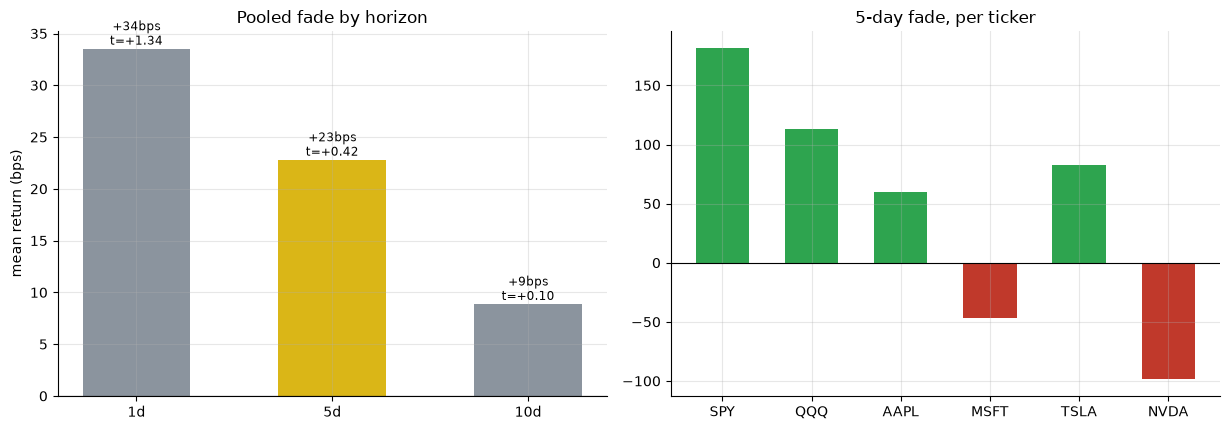

by horizon: {1: 33.5, 5: 22.8, 10: 8.9}
by ticker: {'SPY': 181.7, 'QQQ': 112.7, 'AAPL': 59.5, 'MSFT': -46.5, 'TSLA': 82.5, 'NVDA': -98.6}


In [2]:
if HAVE_REAL:
    shark_by_t = {}
    frames = []
    for t in data.BASKET:
        _, _, l = st.detect_and_scan(BARS[t], pct=PCT, cost_bps=0.0)
        shark_by_t[t] = l
        if len(l):
            frames.append(l)
    SHARK = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    hs = [1, 5, 10]
    means = [st.summarize(SHARK, f'ret_gross_{h}')['mean_bps'] for h in hs]
    ts = [st.summarize(SHARK, f'ret_gross_{h}')['t'] for h in hs]
    per_t = {t: st.summarize(shark_by_t[t], 'ret_gross_5') for t in data.BASKET}
    tick_means = [per_t[t]['mean_bps'] for t in data.BASKET]
else:
    hs = [1, 5, 10]
    means = [R['shark'][h]['mean'] for h in hs]
    ts = [R['shark'][h]['t'] for h in hs]
    tick_means = [R['per_instrument'][t]['mean'] for t in R['basket']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.4, 4.4))
cols1 = [AMBER if h == 5 else GREY for h in hs]
a1.bar([f'{h}d' for h in hs], means, color=cols1, width=.55)
for i, (m, t_) in enumerate(zip(means, ts)):
    a1.annotate(f'{m:+.0f}bps\nt={t_:+.2f}', (i, m), ha='center',
                va='bottom' if m >= 0 else 'top', fontsize=8.5)
a1.axhline(0, c='k', lw=.8); a1.set_title('Pooled fade by horizon')
a1.set_ylabel('mean return (bps)')
cols2 = [GREEN if m > 0 else RED for m in tick_means]
a2.bar(list(R['basket']), tick_means, color=cols2, width=.6)
a2.axhline(0, c='k', lw=.8); a2.set_title('5-day fade, per ticker')
plt.tight_layout(); plt.show()
print('by horizon:', {h: round(m,1) for h,m in zip(hs, means)})
print('by ticker:', {t: round(m,1) for t,m in zip(R['basket'], tick_means)})

> 💡 In plain words: the 5-day pooled fade (**22.81 bps**, HAC *t* = **0.42**) is small and positive, and 10-day (*t* = 0.10) fades further toward zero rather than growing — not the shape of a genuine, strengthening effect. The per-ticker split shows four of six tickers positive, but only SPY individually clears the naive |*t*| ≥ 2 bar, on a thin 11-event sample.

### 4b · The Signal axis — random-day base rate, Bonferroni-corrected

20-seed random-day base rate matched on the empirical bullish/bearish mix of the real touches; Welch *t* vs the Shark ledger, pooled and per ticker; Bonferroni correction across the resulting 7 tests.

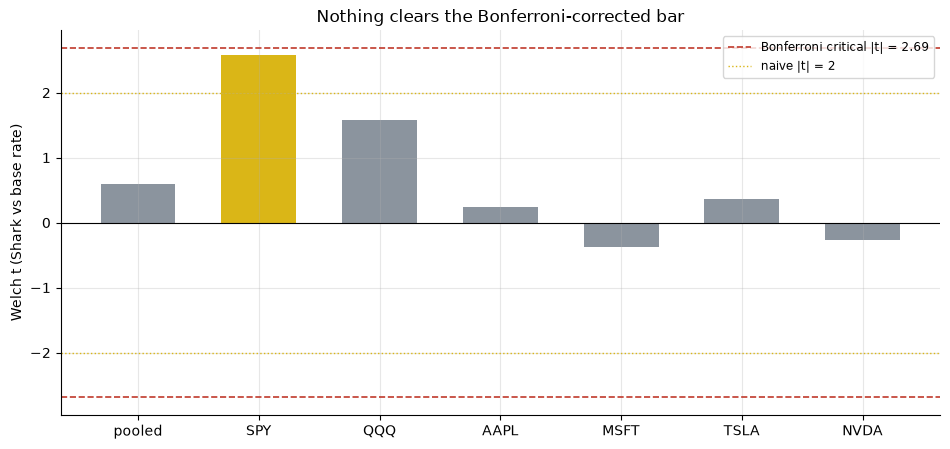

{'pooled': 0.6, 'SPY': 2.57, 'QQQ': 1.58, 'AAPL': 0.24, 'MSFT': -0.37, 'TSLA': 0.36, 'NVDA': -0.27}
Bonferroni critical |t| = 2.69


In [3]:
if HAVE_REAL:
    base_frames, base_by_t = [], {}
    for t in data.BASKET:
        l = shark_by_t[t]
        if len(l):
            mix = float((l['reversal_dir'] > 0).mean())
            bl = pd.concat([st.base_rate_ledger(BARS[t], len(l), mix,
                             seed=st._seed_from(702, t, s)) for s in range(20)],
                            ignore_index=True)
            base_by_t[t] = bl
            base_frames.append(bl)
    BASE = pd.concat(base_frames, ignore_index=True) if base_frames else pd.DataFrame()
    tests = [('pooled', st.welch_t(SHARK['ret_gross_5'], BASE['ret_gross_5']))]
    for t in data.BASKET:
        if t in base_by_t and len(shark_by_t[t]):
            tests.append((t, st.welch_t(shark_by_t[t]['ret_gross_5'], base_by_t[t]['ret_gross_5'])))
        else:
            tests.append((t, float('nan')))
    thr = st.bonferroni_threshold(0.05, len(tests))
else:
    tests = [('pooled', R['base'][5]['t'])] + [
        (t, R['base_per_instrument'][t]['t']) for t in R['basket']]
    thr = R['bonf_thr']
labels = [lbl for lbl, _ in tests]
vals = [v for _, v in tests]
cols = [RED if (np.isfinite(v) and abs(v) >= thr) else
        (AMBER if (np.isfinite(v) and abs(v) >= 2.0) else GREY) for v in vals]
fig, ax = plt.subplots(figsize=(9.6, 4.6))
ax.bar(labels, [v if np.isfinite(v) else 0 for v in vals], color=cols, width=.62)
ax.axhline(0, c='k', lw=.8)
ax.axhline(thr, ls='--', c=RED, lw=1.2, label=f'Bonferroni critical |t| = {thr:.2f}')
ax.axhline(-thr, ls='--', c=RED, lw=1.2)
ax.axhline(2.0, ls=':', c=AMBER, lw=1, label='naive |t| = 2')
ax.axhline(-2.0, ls=':', c=AMBER, lw=1)
ax.set_ylabel('Welch t (Shark vs base rate)')
ax.set_title('Nothing clears the Bonferroni-corrected bar')
ax.legend(fontsize=8.5); plt.tight_layout(); plt.show()
print({lbl: round(v,2) if np.isfinite(v) else None for lbl, v in tests})
print(f'Bonferroni critical |t| = {thr:.2f}')

> 💡 In plain words: only one per-ticker split (SPY, Welch *t* = **2.57**) clears the naive bar of 2 — on just 11 events, the smallest sample of the six. The honest bar, once you correct for looking at six tickers, is **2.69**, and **0/7** tests clear it. This is the desk's multiple-comparison rail doing exactly its job.

### 4c · Tradability — the fade timer, net of costs

Sweep the holding period and the one-way cost; ~4 pooled events/year across six names.

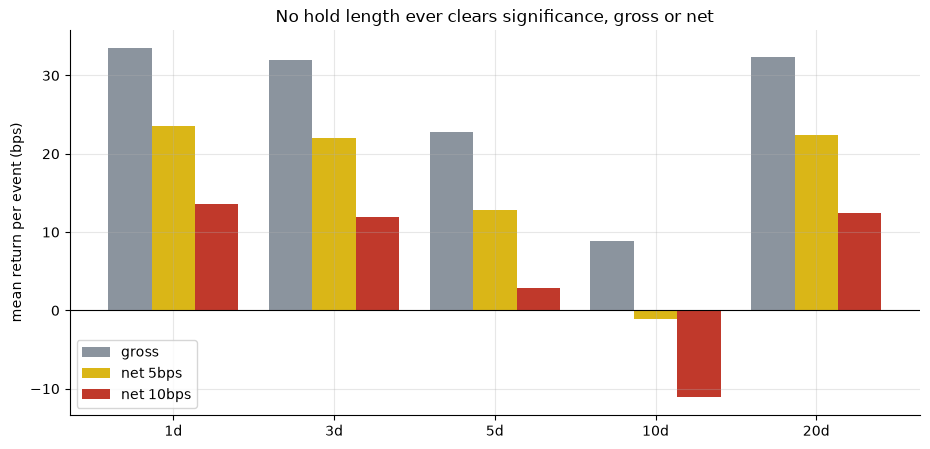

{1: (33.53, 1.34), 3: (31.95, 0.87), 5: (22.81, 0.42), 10: (8.88, 0.1), 20: (32.38, 0.21)}


In [4]:
hs = sorted(R['timer'])
gross = [R['timer'][h]['gross'] for h in hs]
net5 = [R['timer'][h]['net5'] for h in hs]
net10 = [R['timer'][h]['net10'] for h in hs]
x = np.arange(len(hs)); w = .27
fig, ax = plt.subplots(figsize=(9.4, 4.6))
ax.bar(x - w, gross, width=w, label='gross', color=GREY)
ax.bar(x, net5, width=w, label='net 5bps', color=AMBER)
ax.bar(x + w, net10, width=w, label='net 10bps', color=RED)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('mean return per event (bps)')
ax.set_title('No hold length ever clears significance, gross or net')
ax.legend(); plt.tight_layout(); plt.show()
print({h: (R['timer'][h]['gross'], R['timer'][h]['t_gross']) for h in hs})

> 💡 In plain words: costs (5-10 bps round trip) already flip the 10-day hold from marginally positive to marginally negative — there is no cushion here. The *shape* across horizons is not the smooth decay of a real, fading effect either: gross returns dip near zero at 10 days then bounce back up at 20, the signature of sampling noise rather than a decaying edge. Combined with the Bonferroni result above and a firing rate of roughly four completions a year pooled across six names, there is no regime here worth deploying capital against.

### 4d · The third axis — does the specific zone matter?

Identical pivot pipeline; each placebo candidate's D-zone *center* is replaced by a deterministic, seeded, off-band draw.

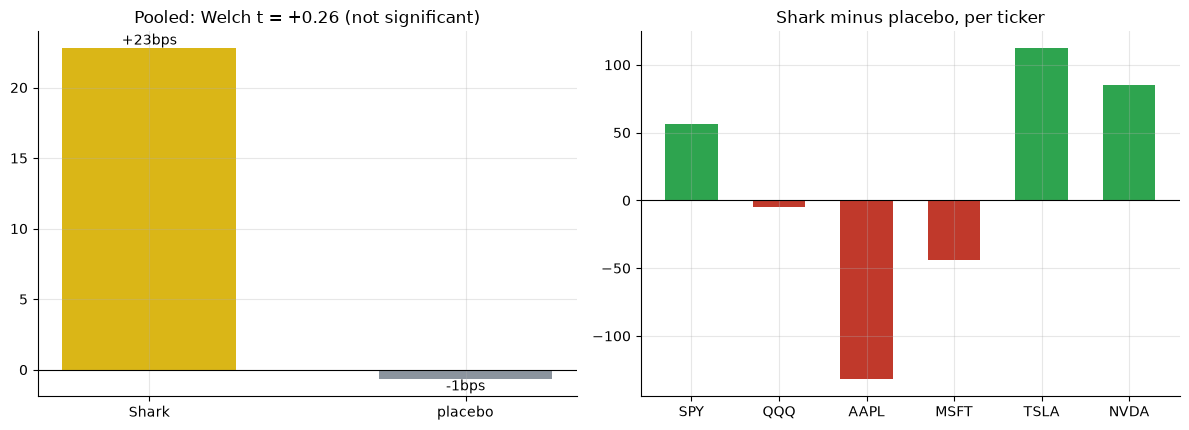

Shark +22.8 bps vs placebo -0.7 bps  Welch t=+0.26


In [5]:
if HAVE_REAL:
    plac_by_t, plac_frames = {}, []
    for t in data.BASKET:
        _, _, lp = st.detect_and_scan(BARS[t], pct=PCT, placebo=True, seed=702, cost_bps=0.0)
        plac_by_t[t] = lp
        if len(lp):
            plac_frames.append(lp)
    PLAC = pd.concat(plac_frames, ignore_index=True) if plac_frames else pd.DataFrame()
    sp = st.summarize(PLAC, 'ret_gross_5')
    pm = sp['mean_bps']
    wtp = st.welch_t(SHARK['ret_gross_5'], PLAC['ret_gross_5'])
    beat_labels, beat_vals = [], []
    for t in data.BASKET:
        fm = st.summarize(shark_by_t[t], 'ret_gross_5')['mean_bps']
        pmi = st.summarize(plac_by_t[t], 'ret_gross_5')['mean_bps']
        beat_labels.append(t); beat_vals.append(fm - pmi if np.isfinite(fm) and np.isfinite(pmi) else np.nan)
else:
    pm, wtp = R['plac'][5]['mean'], R['plac'][5]['t']
    beat_labels = list(R['basket'])
    beat_vals = [R['per_instrument'][t]['mean'] - R['plac_per_instrument'][t]['mean']
                 for t in R['basket']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.0, 4.4))
a1.bar(['Shark', 'placebo'], [R['shark'][5]['mean'], pm], color=[AMBER, GREY], width=.55)
for i, v in enumerate([R['shark'][5]['mean'], pm]):
    a1.annotate(f'{v:+.0f}bps', (i, v), ha='center', va='bottom' if v>=0 else 'top')
a1.axhline(0, c='k', lw=.8)
a1.set_title(f'Pooled: Welch t = {wtp:+.2f} (not significant)')
cols = [GREEN if (np.isfinite(v) and v > 0) else RED for v in beat_vals]
a2.bar(beat_labels, [v if np.isfinite(v) else 0 for v in beat_vals], color=cols, width=.6)
a2.axhline(0, c='k', lw=.8)
a2.set_title('Shark minus placebo, per ticker')
plt.tight_layout(); plt.show()
print(f'Shark {R["shark"][5]["mean"]:+.1f} bps vs placebo {pm:+.1f} bps  Welch t={wtp:+.2f}')

> 💡 In plain words: the Shark beats its own placebo on only **3/6** tickers — a coin flip — and the pooled Welch *t* (**0.26**) is nowhere near significant. The exact 0.886-1.13 completion zone — the Shark's whole selling point, a supposedly more precise *zone* rather than a lucky single number — is not demonstrably better than an arbitrary nearby zone built from the *same* pivots — H₂ not supported.

### 4e · Faithful-engine & power control — we know the truth here

Synthetic mean-reverting price index (tunable `mean_rev` knob toward a slow EMA), pooled across a synthetic 6-name basket per seed. The null (`mean_rev = 0`) is checked over **20 seeds** — never a single stream.

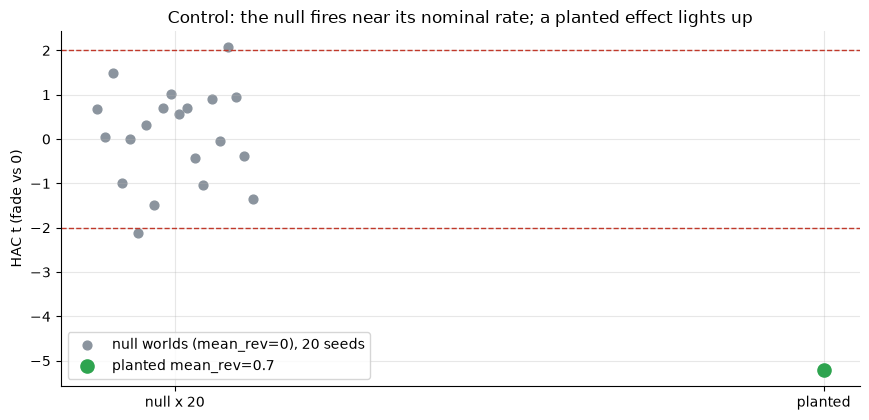

null: mean t = +0.08 (sd 1.07), |t|>=2 in 2/20 seeds  |  planted t = -5.21


In [6]:
def pooled_synth(mean_rev, seed, n_names=6):
    frames = []
    for i in range(n_names):
        sbars = data.synthetic_world(mean_rev=mean_rev, seed=seed*1000+i, n_days=6300)
        _, _, ledger = st.detect_and_scan(sbars, pct=PCT, cost_bps=0.0)
        if not ledger.empty:
            frames.append(ledger)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

null_ts = np.array([st.summarize(pooled_synth(0.0, 702 + s), 'ret_gross_5')['t']
                     for s in range(20)], dtype=float)
planted = pooled_synth(R['syn_planted_mean_rev'], 702)
planted_t = st.summarize(planted, 'ret_gross_5')['t']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12, .12, 20), null_ts, color=GREY, s=40,
           label='null worlds (mean_rev=0), 20 seeds')
ax.scatter([1], [planted_t], color=GREEN, s=90, zorder=5,
           label=f"planted mean_rev={R['syn_planted_mean_rev']}")
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('HAC t (fade vs 0)')
ax.set_title('Control: the null fires near its nominal rate; a planted effect lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {np.nanmean(null_ts):+.2f} (sd {np.nanstd(null_ts, ddof=1):.2f}), '
      f'|t|>=2 in {(np.abs(null_ts) >= 2).sum()}/20 seeds  |  planted t = {planted_t:+.2f}')

> 💡 In plain words: across 20 null worlds the detector fires \|*t*\| ≥ 2 in **2/20** seeds — close to the nominal ~5% false-positive rate — and a strong planted mean-reversion tendency lights up sharply (*t* = **-5.21**). Note the sign runs *opposite* the fade's own `reversal_dir = sign(XA)` convention: the synthetic world's reversion is a generic pull toward a moving average, not specifically anchored to the Shark's X-A geometry, so this is a **power** proof (the pipeline can detect a real reversion tendency when it exists), not a validation of the directional story. The detection + inference pipeline is unbiased; the real-tape result's near-zero signal is genuine, not a bug in the machinery.

## 5 · The verdict

- **Signal `NONE`** — pooled 5-day fade **22.81 bps** (HAC *t* = **0.42**; Welch *t* vs base rate = **0.60**) on **94** touches over 21-25 years; **0/7** Bonferroni-corrected tests survive (critical \|*t*\| = 2.69); the point estimate is not even robust across horizon.
- **Tradability `MIRAGE`** — no hold length (1/3/5/10/20 days) clears |*t*| = 2, gross or net; costs already flip the 10-day hold negative, and the shape across horizons is noise, not decay.
- **"Is 0.886-1.13 the Shark's defining edge?" `BUSTED`** — beats the placebo on only 3/6 tickers (a coin flip), pooled Welch *t* = **0.26** — not statistically demonstrable.

## 6 · Going further

- **The general lesson: structural novelty isn't evidence.** The Shark is the most geometrically distinctive pattern in the harmonic zoo — extension-only legs, a genuine completion zone — and none of that distinctiveness produces a detectable edge once tested mechanically against honest controls. "Different-looking" is not "different-working."
- **Where a believer would push back:** Carney's full method requires a *confluence zone* (several overlapping Fibonacci projections converging near D), not the bare two-ratio-plus-zone skeleton tested here. That's a legitimate next experiment — but it adds researcher degrees of freedom (which projections? how many must converge?) that would need their own placebo before counting as evidence.
- **Dedup map:** [468-gartley-harmonic](../../468-gartley-harmonic/) (every leg a retracement, D never leaves X-A), [698-abcd-harmonic](../../698-abcd-harmonic/) (no X point, no confluence at all), [699-butterfly-harmonic](../../699-butterfly-harmonic/) (fixed 0.786 B retracement, D a 1.27-1.618 range past X), [700-bat-harmonic](../../700-bat-harmonic/) (D stays inside X-A), [701-crab-harmonic](../../701-crab-harmonic/) (a single sharp 1.618 point target) and [703-cypher-harmonic](../../703-cypher-harmonic/) (D measured off the XC leg, not XA) — all independently converging on the same verdict shape across wildly different XABCD geometries.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*